In [2]:
# Bron:
# 0_PE_Challenge - slide 3 -> Jupyter notebook, EDA, model, confusion matrix
# 3_ML_Classification - slide 12 -> Given X -> Predict y
# 4_ML_Regression - slide 20 -> onafhankelijke variabelen = X, afhankelijke variabele = y

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# Pas bestandsnamen aan indien nodig
train_df = pd.read_csv("train_CarBreakDown.csv")
test_df = pd.read_csv("test_CarBreakDown.csv")

print(train_df.head())
print(train_df.shape)
print(test_df.shape)

     id vehicle_brand  vehicle_age_years     mileage_km  engine_hours  \
0   959        Toyota               20.0  494744.972722   9700.481467   
1   804        Toyota                0.0   38376.684834   1650.726428   
2  1304       Hyundai                1.0  188558.432414   6678.958321   
3   268        Toyota                5.0   92828.113285   2986.923461   
4    47           NaN               10.0  118366.394287   4222.193011   

   last_service_km_ago  oil_quality_pct  avg_trip_length_km weather_exposure  \
0          1672.048445        61.664556           30.362090             high   
1            21.269170        23.370666            2.500801             high   
2         11726.320455        25.491428           41.692205           medium   
3          1845.744691        54.060416            6.464345             high   
4         12551.181627        65.766074           47.159242              low   

  fuel_type  cleanliness_score  driver_satisfaction_score tyre_type  \
0    petr

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         1050 non-null   int64  
 1   vehicle_brand              1029 non-null   object 
 2   vehicle_age_years          1034 non-null   float64
 3   mileage_km                 1033 non-null   float64
 4   engine_hours               1035 non-null   float64
 5   last_service_km_ago        1040 non-null   float64
 6   oil_quality_pct            1014 non-null   float64
 7   avg_trip_length_km         1038 non-null   float64
 8   weather_exposure           1037 non-null   object 
 9   fuel_type                  1036 non-null   object 
 10  cleanliness_score          995 non-null    float64
 11  driver_satisfaction_score  1037 non-null   float64
 12  tyre_type                  1033 non-null   object 
 13  breakdown_next_30_days     1050 non-null   int64

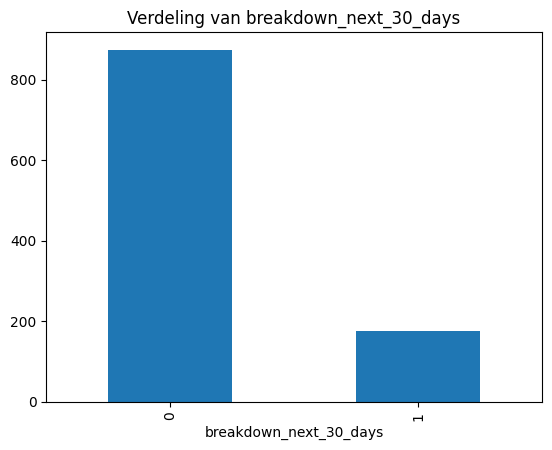

In [4]:
# Bron:
# 0_PE_Challenge - slide 3 -> Perform EDA on the data
# 3_ML_Classification - slide 8 -> Machine Learning runs on DATA
# 3_ML_Classification - slide 20 -> Structured Data

print(train_df.info())
print(train_df.isnull().sum())
print(train_df.describe(include="all"))

# Verdeling van de target bekijken
print(train_df["breakdown_next_30_days"].value_counts())

train_df["breakdown_next_30_days"].value_counts().plot(kind="bar")
plt.title("Verdeling van breakdown_next_30_days")
plt.show()

In [5]:
# Bron:
# 3_ML_Classification - slide 12 -> Given X -> Predict y
# 4_ML_Regression - slide 20 -> onafhankelijke variabelen = X, afhankelijke variabele = y

y = train_df["breakdown_next_30_days"]

X = train_df.drop(columns=[
    "breakdown_next_30_days",
    "id"
])

# Testset voorbereiden
X_kaggle = test_df.drop(columns=["id"])

In [6]:
# Bron:
# 3_ML_Classification - slide 45 -> Encoding: one-hot vs label

X = pd.get_dummies(X)
X_kaggle = pd.get_dummies(X_kaggle)

# Zorg dat train en test dezelfde kolommen hebben
X, X_kaggle = X.align(X_kaggle, join="left", axis=1, fill_value=0)

In [7]:
# Bron:
# 3_ML_Classification - slide 23 -> training dataset <-> test dataset
# 3_ML_Classification - slide 30 -> train / validation / test set
# 3_ML_Classification - slide 47 -> split data into train and test set

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(840, 30)
(210, 30)


In [8]:
# Bron:
# 0_PE_Challenge - slide 3 -> First, use a Random Forest as a benchmark
# 3_ML_Classification - slide 51 -> Ensemble Learning Random Forest
# 3_ML_Classification - slide 55 -> Random Forest overview
# 3_ML_Classification - slide 59 -> Scikit-learn makes life easy

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [9]:
# Bron:
# 3_ML_Classification - slide 25 -> fitting a model
# 3_ML_Classification - slide 47 -> evaluate it on the test set
# 3_ML_Classification - slide 48 -> classification: accuracy

from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8285714285714286


[[173   2]
 [ 34   1]]


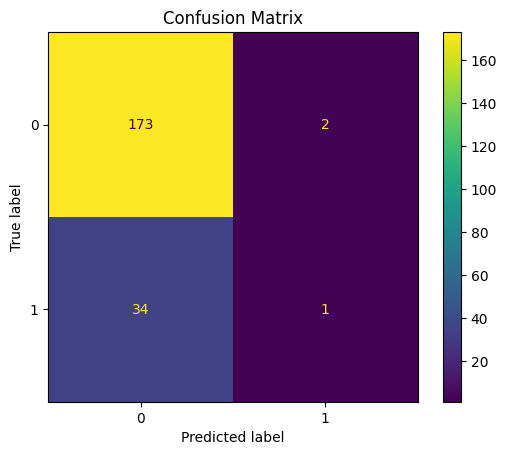

In [10]:
# Bron:
# 0_PE_Challenge - slide 3 -> Evaluation of the model, including a confusion matrix
# 3_ML_Classification - slide 49 -> Confusion Matrix
# 4_ML_Regression - slide 11 -> Evaluation

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()

In [11]:
# Bron:
# 0_PE_Challenge - slide 3 -> Valid Kaggle submission

kaggle_predictions = model.predict(X_kaggle)

In [12]:
submission = pd.DataFrame({
    "id": test_df["id"],
    "breakdown_next_30_days": kaggle_predictions
})

submission.to_csv("submission.csv", index=False)

print(submission.head())

     id  breakdown_next_30_days
0  1356                       0
1   889                       0
2  1190                       0
3   122                       0
4  1101                       0
